# Trapezoidal Filtering 1

Jacon and Gerard keep talking about trapezoidal filters as the way to extract energy information from the proton detector traces. I want to take a look at this technique and to compare it with some other techniques that seem naively suitable. This is partly in response to this from Gordon
>3) Jason is great, but I would feel better if the BL3 reducer and analysis had
>a second independent person working on them.  Who would have the expertise for that? >On a related note, who would think to demonstrate their analysis technique using
>a schematic or actual pulse shape, and trapezoidal filter shape, etc.?

So let's see if we can illuminate some things using some of the preliminary data from Gerard, which I have already started to analyze in Spyder. I have a program, `PrelimPdat1.py`, that reads one of Gerard's giant text files and breaks it up into a set of separate channel data files. The files `Channel<n>.txt` each hold just over 62k events from one of the six instrumented proton detector channels of this early test. The source was some fraction of 1 µCi of Cd-109 placed about 10 cm from the detector face in an environmental chamber cooled to -75 C and biased at -50V.

The channel files can be read into ChData objects from which individual Event objects can be spawned using the tools in `ChDat.py`. Let's start with our tools. I am going to use `matplotlib` as I have not got the hang of `plotly` yet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ChDat import ChData, Event

Channel 3 appears to contain the largest number of detectable events so I will use that for my test case. Let's open it and look at the spectrum.

Read 62729 events.


<Axes: title={'center': 'pixel 60 (ring 6)\n'}, xlabel='tADC Units', ylabel='Count'>

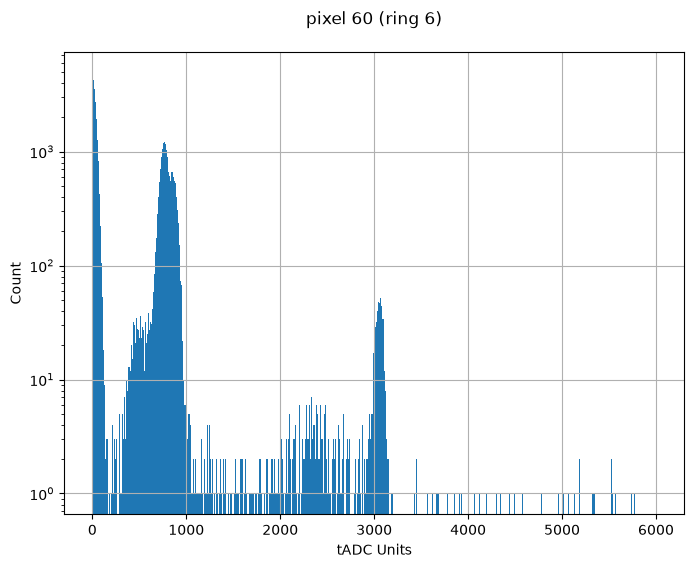

In [3]:
ch3 = ChData('Channel3.txt', npoint = 62729 )
ch3.plot_hist()

On the far left is the noise wall, up to about 200 ADC units, followed by the two Cd-109 x-rays and their Compton features. Then comes a rather wide gap before we get to the 88 keV Cd-109 gamma along with its Compton features. The peak of the 88 keV line reaches about 50 events, so there are a few hundred such events in toto.

Let's look at a typical event. I know from prior testing that event 4 is worth a look.

<Axes: >

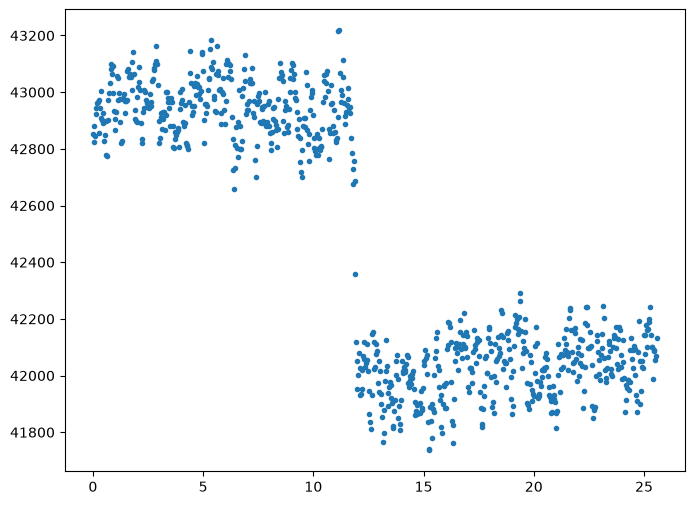

In [4]:
evt4 = ch3.get_event(4)
evt4.plot()

That event has a magnitude somewhere near 1000 and is thus at the high energy end of the x-ray peaks. We see that the pulse rise-time is very short, fewer than 10 samples in width (10 * 0.032 = 0.32 µs), and that although there is noise at the level of 10 % of the event magnitude we can see that the data after the event are starting to slope back up toward the pedestal.

Now my immediate thought is to fit that with a background plus a linear edge (falling) and then essentially linear decay (rise) and to infer the magnitude of the originatin pulse from the meeting point of the edge and decay. That involves a fit that includes the non-linear dependance on the position of the edge, which is always near the center but not exactly reproducible.

However, the standard trapezoidal algorithm is closer to the convolution of the data with a simple edge function. Indeed, the standard algorithm does the convolution with a function that starts at -1 for a fixed width, is zero for a short time chosen to cover the data edge time, and +1 for the same width as the original. Because of the effect on the output of the convolution these are called the rise time, the flat-top, and the fall-time. In principle the rise and fall time could be made different but that does not seem to be the usual practice.

Let's look at that process graphically. We'll start with some synthetic data, which we will make positive for pedagogic clarity. We'll make the height 2.22 so that we can recognize it in any results and we'll stick it on a baseline of 5.5

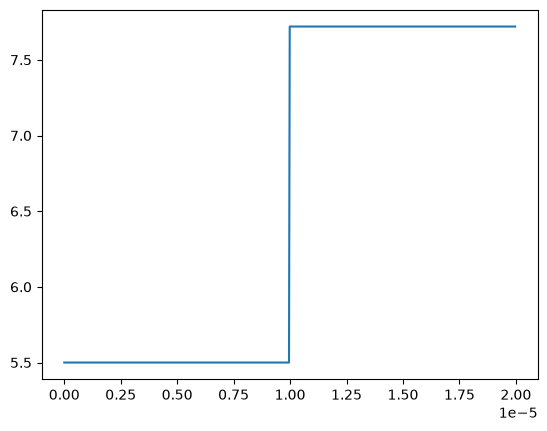

In [7]:
time = np.arange(0.0, 2.0e-5, 0.032e-6)
npt = len(time)
syn_dat = np.empty(npt)
syn_dat[:int(npt/2)] = 5.5
syn_dat[int(npt/2):] = 5.5 + 2.22
plt.plot(time, syn_dat)

Now let's look at the kernel of our filter. Just to keep it simple I will use rise and fall times of 1 µs and a flat top of 0.5 µs for a total duration of 2.5 µs.

47


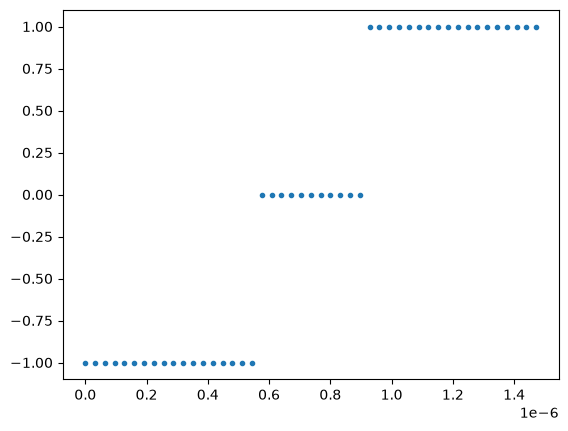

In [9]:
ktime = np.arange(0, 1.5e-6, 0.032e-6)
nkt = len(ktime)
print(nkt)
k5 = int(nkt/5)
kernel = np.zeros(nkt)
kernel[:2*k5] = -1
kernel[-2*k5:] = +1
plt.plot(ktime, kernel, '.')

Now offset the kernel from the start of the data by some number of samples, I'll use 10 in the example, so that we get something like this

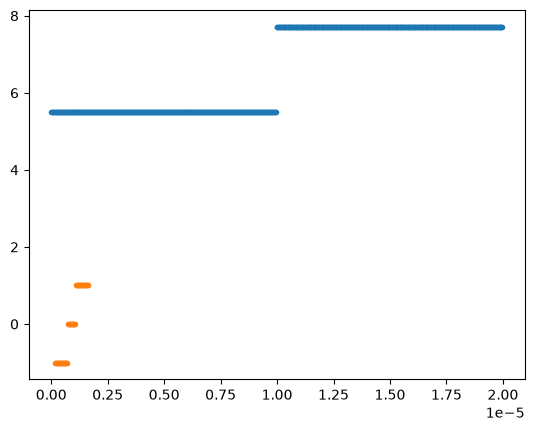

In [11]:
plt.plot(time, syn_dat, '.')
plt.plot(ktime + 5 * 3.2e-8, kernel,'.')

Then we multiply the two curves toether and sum the result. If we do that in this position then we expect to get zero since the rise and fall regions will both sample the same value and thus cancel. Let's see that.

In [12]:
sum = 0
for i in range(nkt):
    sum += kernel[i] * syn_dat[i + 5]
print(sum)

0.0


That state of affairs will continue until we start to reach the edge. So when the offset reaches 300 we get

26.639999999999993


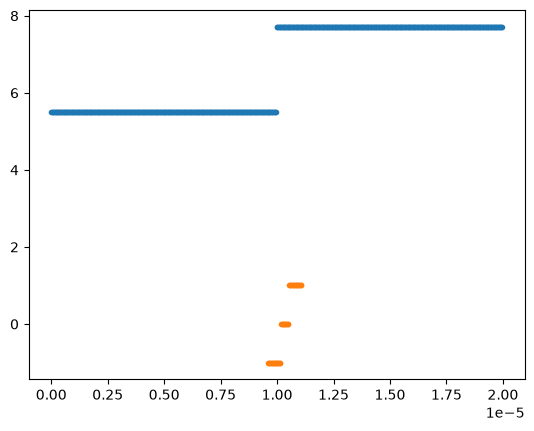

In [15]:
offset = 300
plt.plot(time, syn_dat, '.')
plt.plot(ktime + offset * 3.2e-8, kernel,'.')
sum600 = 0
for i in range(nkt):
    sum600 += kernel[i] * syn_dat[i + offset]
print(sum600)

The sum will continue to increase until the edge lies in the gap, when it will stay constant. After that the sum will start to decrease again until the kernel is entirely under the upper edge when it will be zero. So if we plot the sum as a function of the offset then we get

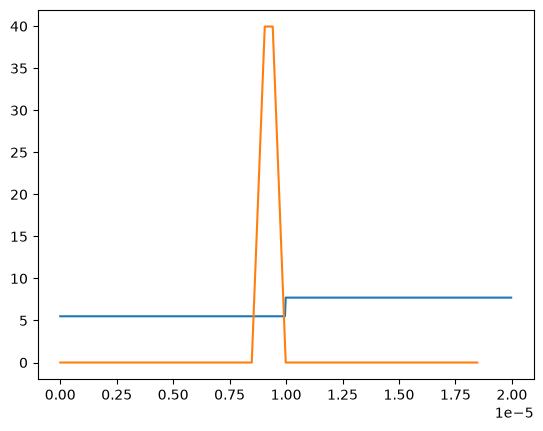

In [21]:
noverlap = npt - nkt
sums = np.zeros(noverlap)
offsets = time[:noverlap]
for offset in range(noverlap):
    for i in range(nkt):
        sums[offset] += kernel[i] * syn_dat[i + offset]
plt.plot(time, syn_dat)
plt.plot(offsets, sums)

So the last thing that we need to do is to scale out the width of the rise/fall time so that we are plotting averages rather than sums. The better way would have been to set the weighting of the kernel so that each of the rise and fall regions would sum to magnitude zero rather than to magnitude equal to the length of the region.

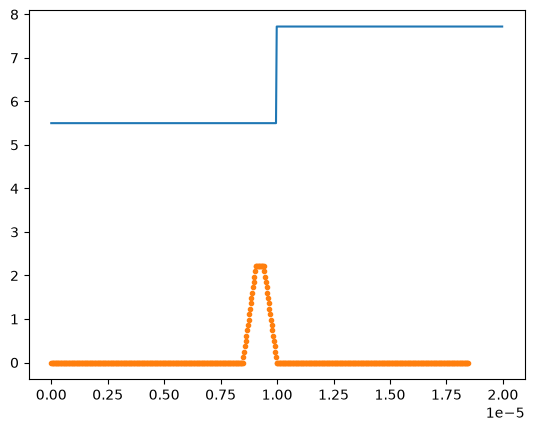

In [25]:
plt.plot(time, syn_dat)
plt.plot(offsets, sums/(2 * k5), '.')

And there is the origin of the term 'trapezoidal filter'. If you feed an edge in then you get a trapezoid out and the height of the flat-top is the value of the edge height.

Now what happens if instead of a simple Heaviside edge we feed in a more realistic pulse with a rise-time and then a fall time (short enough to be considered linear)? I am going to make the rise take 10 samples and then do a fall time long enough to make the value fall by 0.2 in 10 us, so slope = 0.2 / 1e-5 = 20,000

7.7064 7.50032


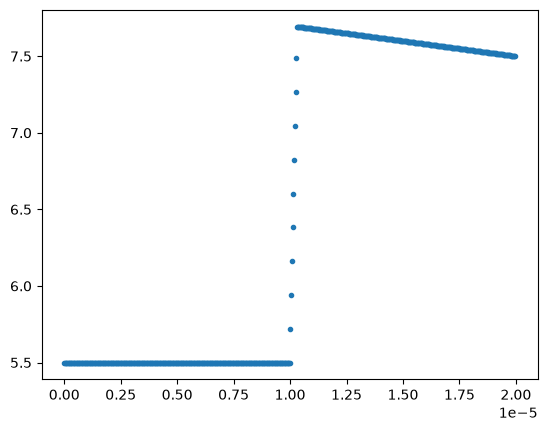

In [32]:
p_dat = np.empty(npt)
hpt = int(npt/2)
dt = 0.032e-6
rise_t = 10 * dt
base = 5.5
height = 2.2
falling_slope = -20_000
intercept = base + height - falling_slope * rise_t
rising_slope = (intercept - base) / rise_t
p_dat[:hpt] = base
p_dat[hpt:hpt+10] = base + time[:10] * rising_slope
p_dat[hpt+10:] = base + height + falling_slope * (time[hpt+10:] - time[hpt])
plt.plot(time, p_dat, '.')
print(intercept, p_dat[-1])

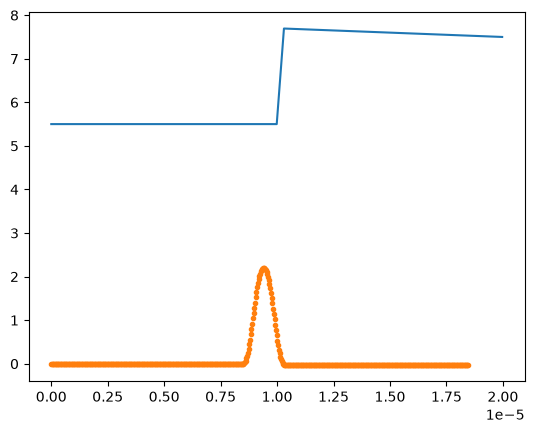

In [34]:
psums = np.zeros(noverlap)
for offset in range(noverlap):
    for i in range(nkt):
        psums[offset] += kernel[i] * p_dat[i + offset]
plt.plot(time, p_dat)
plt.plot(offsets, psums/(2*k5), '.')

If you look carefully then you will see that the tail of the output is at a slightly lower level than the lead-ing. Let's look at that difference and at the maximum.

In [36]:
cpsums = psums/(2*k5)
print(cpsums[0], cpsums[-1], np.max(cpsums))

0.0 -0.018559999999998775 2.1881600000000003


In [37]:
print(np.max(cpsums)- cpsums[-1])

2.206719999999999


So the 2.2 that we started with is pretty darn close to the maximum of the traezoidal filter. The average over the nominal flat top of the trap filter would be significantly worse.

Now this was a little unfair as I made the rise time of the pulse LONGER than the flat-top time, removing any flat-top from the output.

Let's write a function to create a trap-filter kernel given two parameters, the rise time and flat-top, both specified in terms of the number of samples.

In [42]:
def trap_kernel(n_rise, n_flat):
    nr = int(n_rise)
    nf = int(n_flat)
    ker = np.zeros(2 * nr + nf)
    mag = 1.0 / nr
    ker[:nr] = -mag
    ker[nr + nf:] = mag
    return ker

We should be able to apply this using the numpy convolve operator. Let's repeat our previous example this way but this time with wider kernel so the flat top is wider than the rise of the edge.

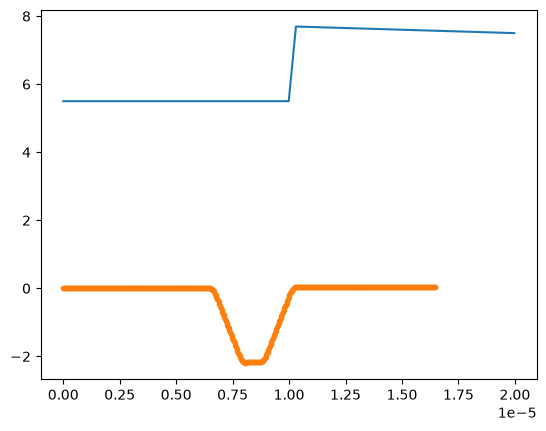

In [43]:
ker2 = trap_kernel(40, 30)
out2 = np.convolve(p_dat, ker2, mode='valid')
nout = len(out2)
plt.plot(time, p_dat)
plt.plot(time[:nout], out2, '.')

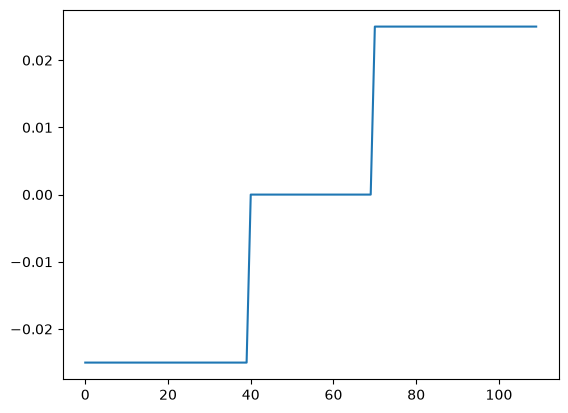

In [44]:
plt.plot(ker2)

Ah, convolve reverses the kernel. A small change to trap_kernel will fix this.

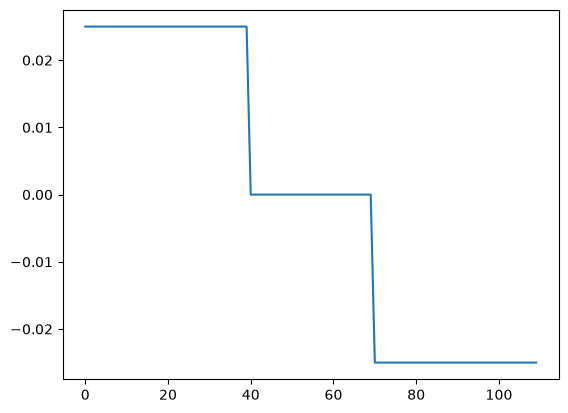

In [45]:
def trap_kernel(n_rise, n_flat):
    nr = int(n_rise)
    nf = int(n_flat)
    ker = np.zeros(2 * nr + nf)
    mag = 1.0 / nr
    ker[:nr] = mag
    ker[nr + nf:] = -mag
    return ker

ker3 = trap_kernel(40, 30)
plt.plot(ker3)

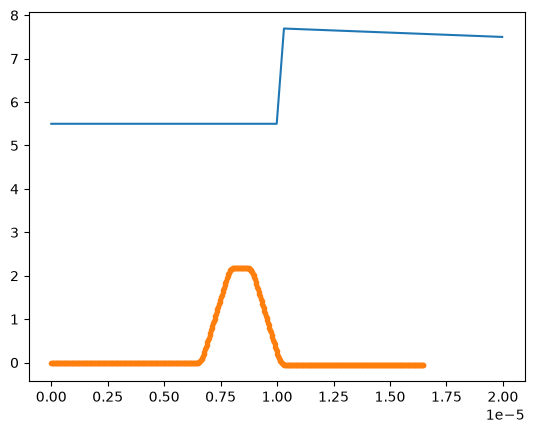

In [46]:
out3 = np.convolve(p_dat, ker3, mode='valid')
nout = len(out2)
plt.plot(time, p_dat)
plt.plot(time[:nout], out3, '.')

In [47]:
print(np.max(out3))

2.1811200000000004


The rise time of the trapezoid will now be the sum of the signal rise time and the filter rise time while the flat top will be shorter by (I think) twice the signal rise time.

Now what happens if I bury my signal in noise? Let's start with 10 % noise.

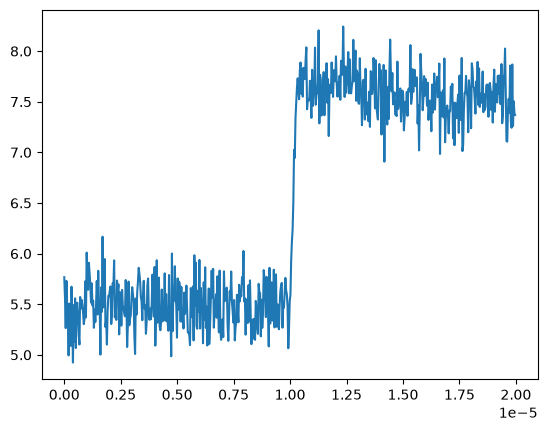

In [48]:
rng = np.random.default_rng()
noise10 = rng.normal(scale=0.22, size=npt)
np10 = p_dat + noise10
plt.plot(time, np10)


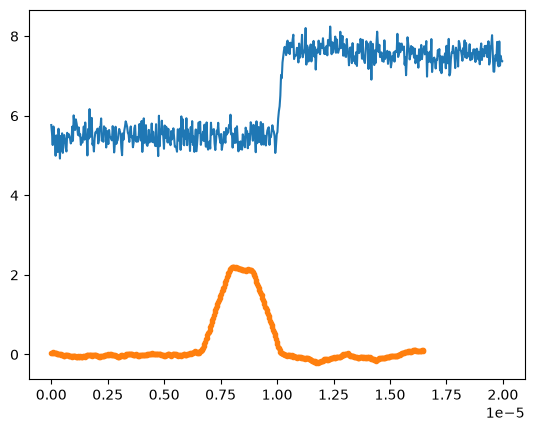

In [49]:
nout10 = np.convolve(np10, ker3, mode='valid')
nout = len(nout10)
plt.plot(time, np10)
plt.plot(time[:nout], nout10, '.')

In [50]:
print(np.max(nout10))

2.1939102750501043


So we altered our output value by about 0.5 %.

What about 50 % noise?

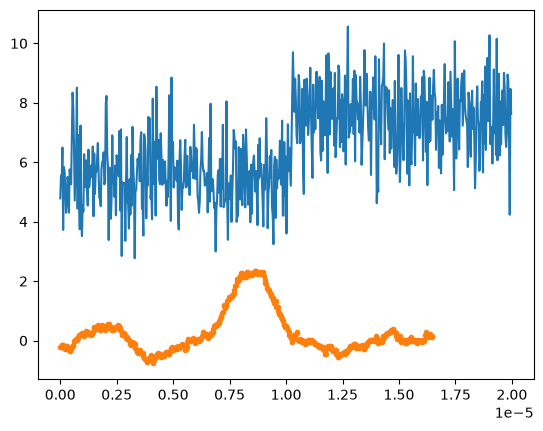

In [51]:
noise50 = rng.normal(scale=0.5 * 2.2, size=npt)
np50 = p_dat + noise50
nout50 = np.convolve(np50, ker3, mode='valid')
nout = len(nout50)
plt.plot(time, np50)
plt.plot(time[:nout], nout50, '.')

Well, the output is now pretty seriously noisy. The edge is still rather visible to the eye and the peak is still a peak but the edges are a real mess. Let's look at the magic answer.

In [52]:
print(np.max(nout50))

2.3426940469743878


Our error has now reached about 0.15 or about 6.8 %. Still pretty decent. We might try a larger filter with this kind of noise. It should do a better job of flattening the edges with a larger averaging radius. Let's try twice as wide.

2.3824793293250575


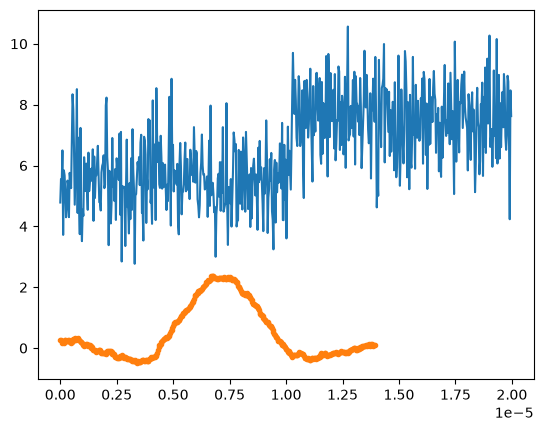

In [53]:
ker4 = trap_kernel(80, 30)
nout504 = np.convolve(np50, ker4, mode='valid')
nout = len(nout504)
plt.plot(time, np50)
plt.plot(time[:nout], nout504, '.')
print(np.max(nout504))

Well, it made the edges smoother but the peak value is actually worse, using the exact same data. Note that the 50 % noise here means that the standard deviation of the noise is 50 % of the step value so that the peak-peak noise in both the lead-in and lead-out regions is actually larger than the step.

So, what happens if we apply our trap filter, and I will use the wider one, to our actual data?

800


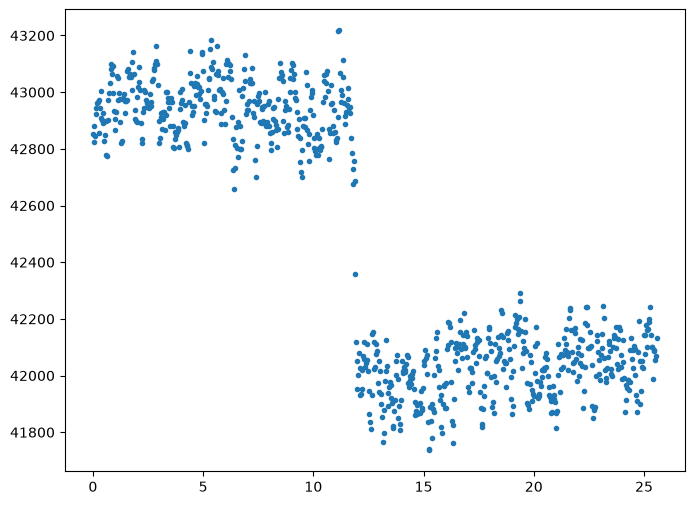

In [55]:
evt4.plot()
npt_e4 = len(evt4.times)
print(npt_e4)

119.08750000000215


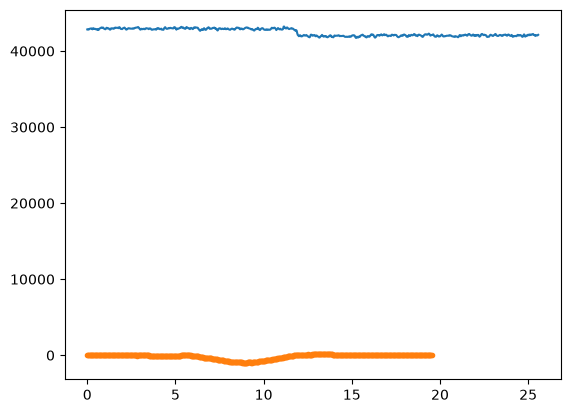

In [56]:
f80_ev4 = np.convolve(evt4.vals, ker4, mode='valid')
nout = len(f80_ev4)
plt.plot(evt4.times, evt4.vals)
plt.plot(evt4.times[:nout], f80_ev4, '.')
print(np.max(f80_ev4))

-969.3375000000016


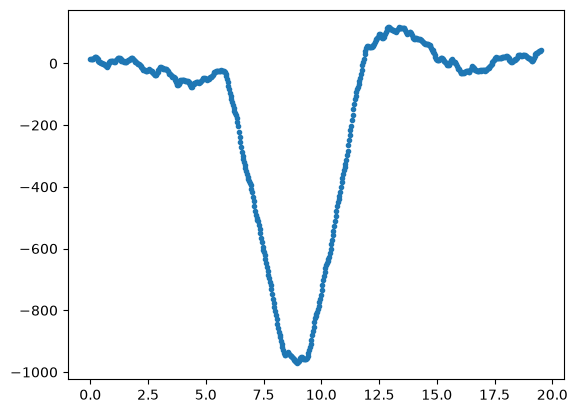

In [58]:
plt.plot(evt4.times[:nout], f80_ev4, '.')
print(np.min(f80_ev4))

Well, that has done very much what we would expect and extracted a value near 1000, again as we expect. I would like longer traces to run wider rise times but I will have to wait for Jason's new data for that. Let's compare this with my simple data fitting to two straight lines model.

In helper params=[42851.     0. 42134.     0.]
In model params=[42851.     0. 42134.     0.]
In helper params=[42851.00000001     0.         42134.             0.        ]
In model params=[42851.00000001     0.         42134.             0.        ]
In helper params=[4.28510000e+04 1.49011612e-08 4.21340000e+04 0.00000000e+00]
In model params=[4.28510000e+04 1.49011612e-08 4.21340000e+04 0.00000000e+00]
In helper params=[42851.             0.         42134.00000001     0.        ]
In model params=[42851.             0.         42134.00000001     0.        ]
In helper params=[4.28510000e+04 0.00000000e+00 4.21340000e+04 1.49011612e-08]
In model params=[4.28510000e+04 0.00000000e+00 4.21340000e+04 1.49011612e-08]
In helper params=[ 4.28510517e+04  2.58608974e-01  4.21339483e+04 -9.73586725e-01]
In model params=[ 4.28510517e+04  2.58608974e-01  4.21339483e+04 -9.73586725e-01]
In helper params=[ 4.28510517e+04  2.58608974e-01  4.21339483e+04 -9.73586725e-01]
In model params=[ 4.28510517e+0

<Axes: >

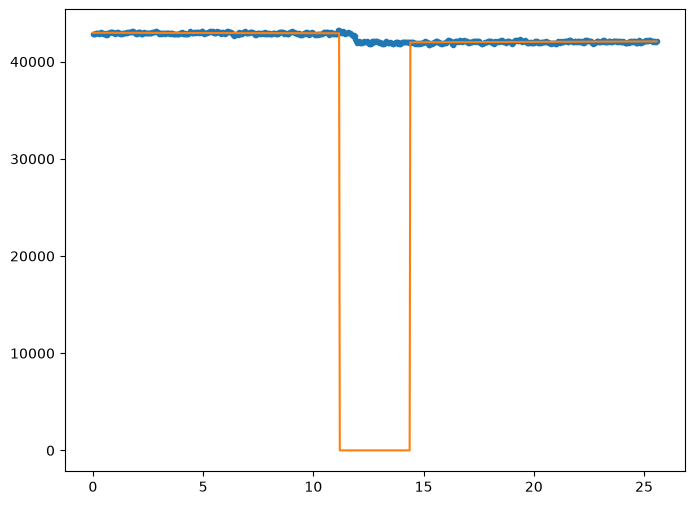

In [64]:
p0 = [evt4.vals[0], 0, evt4.vals[-1], 0]
r = evt4.fit_to(p0)
print(r)
evt4.plot()

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 178031245798.99042
        x: [ 4.297e+04 -4.141e+00  4.186e+04  8.770e+00]
      nit: 10
      jac: [ 0.000e+00  4.096e+03  0.000e+00 -4.096e+03]
 hess_inv: [[ 1.625e-03 -7.806e-05  5.906e-05  6.265e-11]
            [-7.806e-05  1.528e-05 -3.407e-06 -8.352e-12]
            [ 5.906e-05 -3.407e-06  1.312e-03 -2.233e-10]
            [ 6.265e-11 -8.352e-12 -2.233e-10  1.120e-11]]
     nfev: 145
     njev: 29


<Axes: >

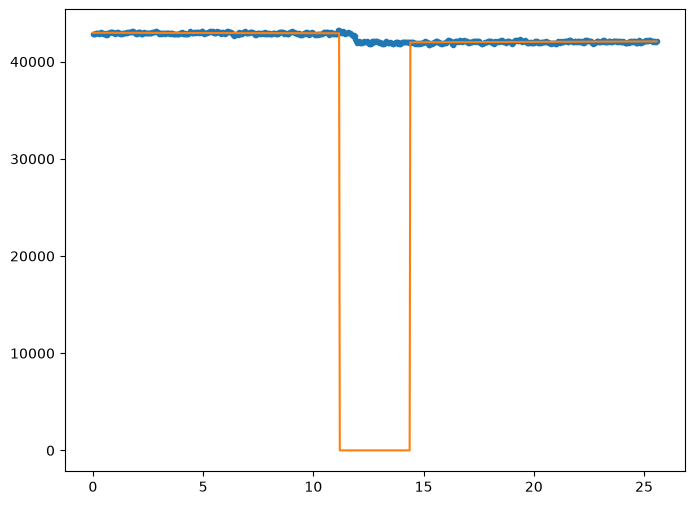

In [65]:
print(r)
evt4.plot()

This gives us a height estimate from the difference in left and right baselines of

In [60]:
print(r.x[0], r.x[2], r.x[0] - r.x[2])

42971.43284713382 41860.00300038109 1111.4298467527333


So my algorithm extracts a rather larger value than the trapezoidal algorithm. Note that the slopes are so small that they make little difference. An alternative algorithm would be to use the last point on the left and the first point on the right to get our difference.

In [63]:
print(evt4.fit_vals[349], evt4.fit_vals[450], evt4.fit_vals[349] - evt4.fit_vals[450]) 

42925.186980393344 41986.296830373976 938.8901500193679


So this method gives an answer smaller than the trapezoidal method. All three of these answers seem like sensible values so their differences tell us something about the accuracy or the biases of the methods. Since we really have no idea what the 'right' answer is in this case we don't learn an awful lot.

A more interesting study would be to plot the spectra using the three different methods and to look at the widths of the x-ray and gamma peaks. Maybe that is the next trial.